# 07 - Shared human-vehicle control

**Goal.** Turn the integrity score into *action*. Instead of a brittle all-or-nothing
handover, we blend the automation and driver commands with an **authority** that
follows integrity, model an imperfect human, analyse the stability of the blended
loop, and show how the same integrity signal arbitrates a driver/automation conflict.

## 1. Levels of automation and the handover problem

Partial automation (SAE levels 2-3 [1]) keeps the human in a supervisory role, which
is exactly where humans are worst: taking a person who is **out of the loop** and
asking them to resume control takes seconds and is error-prone [2,3]. A *hard*
handover - automation drops out, human must instantly take over - inherits all of
that risk, and it also throws away the automation's contribution the moment it is
flagged. The alternative is to keep *both* agents in the loop and shift authority
*smoothly*.

## 2. Haptic shared control

In **haptic shared control** both the driver and the automation act on the same
control channel simultaneously; their commands are blended rather than switched
[4,5,6]. We use an input-mixing form on the steering:

$$ \boxed{\;\delta = \delta^{ff} + \lambda\,\delta_A + (1-\lambda)\,\delta_H\;}\qquad \lambda\in[0,1], $$

with $\lambda$ the **automation authority**: $\lambda=1$ is full automation, $\lambda=0$
is the driver (plus the map-based feed-forward $\delta^{ff}$, which always applies -
notebook 02). Blending, rather than switching, means neither agent is ever fully
out of the loop, the transition is continuous, and the driver feels the automation's
intent through the shared actuator [4]. The design question is how to set $\lambda$;
we tie it to integrity.

## 3. A driver model: the crossover idea

To reason about the loop we need a model of the human. The classic result is
McRuer's **crossover model** [7]: a well-trained operator adapts their own dynamics
so that the *open-loop* human+plant behaves like

$$ Y_{OL}(j\omega)\approx \frac{\omega_c\,e^{-j\omega\tau}}{j\omega} $$

near the crossover frequency $\omega_c$, with an effective reaction delay
$\tau\approx 0.2$-$0.4$ s from neuromuscular and processing lags. The delay is the
crux: it erodes phase margin, so a human with *too much* delay or gain goes unstable.
Our discrete driver is a minimal realisation of this - a delayed, noisy proportional
controller on the lane error,

$$ \delta_H = -(1-\tfrac12 W)\,K_h^\top x_{k-\tau} + w_k,\qquad
   w_k\sim\mathcal N\!\big(0,(\sigma_h(1+2W))^2\big), $$

where $W$ is workload (next section). We choose $K_h$ and $\tau$ so the human is
**stabilising but clearly worse than the automation** - a viable fallback, not a
perfect one. Let us verify the delay really is the stability-limiting factor - and see
that, at its own 0.2 s delay, our driver is only just stable.

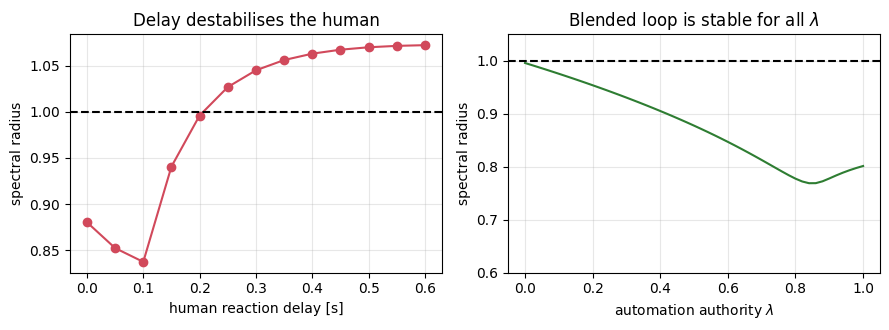

human-only stable up to 0.20 s of delay, unstable from 0.25 s; our driver uses tau=4 (0.20 s), spectral radius 0.996


In [1]:
import numpy as np, matplotlib.pyplot as plt
L, Ts, V = 2.7, 0.05, 15.0
A = np.array([[1, V*Ts], [0, 1.]]); B2 = np.array([[0.], [V*Ts/L]]); Bv = B2.ravel()

def dlqr(A, B, Q, R, it=800):
    P = Q.copy()
    for _ in range(it): P = Q + A.T@P@A - A.T@P@B@np.linalg.solve(R + B.T@P@B, B.T@P@A)
    return np.linalg.solve(R + B.T@P@B, B.T@P@A)

KA = dlqr(A, B2, np.diag([1., 5.]), np.array([[8.]])).ravel()   # automation (LQR) gain
KH = np.array([0.12, 0.9])                                      # human proportional gain

def blended_poles(lam, tau):
    # spectral radius of the delayed blended closed loop (augmented state)
    n, d = 2, tau + 1
    Z = np.zeros((n*d, n*d))
    Z[0:n, 0:n] = A - lam*np.outer(Bv, KA)                     # automation acts on x_k
    Z[0:n, n*tau:n*tau+n] += -(1 - lam)*np.outer(Bv, KH)       # human acts on x_{k-tau}
    for j in range(1, d):
        Z[n*j:n*j+n, n*(j-1):n*(j-1)+n] = np.eye(n)            # delay shift register
    return np.max(np.abs(np.linalg.eigvals(Z)))

taus = np.arange(0, 13)
rho_human = [blended_poles(0.0, t) for t in taus]              # human-only vs delay
lams = np.linspace(0, 1, 51)
rho_blend = [blended_poles(l, 4) for l in lams]               # blended vs authority (tau=4)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(taus*Ts, rho_human, 'o-', color="#d1495b"); ax[0].axhline(1, ls='--', color='k')
ax[0].set(xlabel="human reaction delay [s]", ylabel="spectral radius", title="Delay destabilises the human")
ax[1].plot(lams, rho_blend, color="#2e7d32"); ax[1].axhline(1, ls='--', color='k')
ax[1].set(xlabel="automation authority $\\lambda$", ylabel="spectral radius",
          title="Blended loop is stable for all $\\lambda$", ylim=(0.6, 1.05))
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()
first_bad = taus[np.argmax(np.array(rho_human) > 1)]          # first delay with spectral radius > 1
print("human-only stable up to %.2f s of delay, unstable from %.2f s; our driver uses tau=4 (0.20 s), spectral radius %.3f"
      % (Ts*(first_bad - 1), Ts*first_bad, rho_human[4]))

## 4. Workload and performance

Human performance is not fixed; it follows the **Yerkes-Dodson** inverted-U [8]: too
little or too much arousal/workload degrades it. Under high workload a driver's
corrections get noisier and less forceful, and takeover is slower. We fold a scalar
workload $W\in[0,1]$ (think of a normalised NASA-TLX [10]) into the driver model in
two ways: it **inflates the steering noise** ($\sigma_h(1+2W)$) and **attenuates the
gain** ($1-\tfrac12 W$). Workload-adaptive haptic control - handing more to the
automation when the driver is loaded, provided the automation is trustworthy - is an
active research direction [9], and it is exactly what our authority law below does.

## 5. The authority law and the operating envelope

We set authority from integrity $I$ and workload $W$:

$$ \lambda=\mathrm{clip}\!\big(I+\rho\,W\,(I-0.5),\ \lambda_{\min},\ \lambda_{\max}\big),
   \qquad [\lambda_{\min},\lambda_{\max}]=[0.05,0.95]. $$

Three design choices are encoded here (with $\rho=0.35$). Authority **rises with integrity** -
trust the automation when the monitor says it is trustworthy. The **workload term is
signed about $I=0.5$**, so workload makes the arbitration *more decisive*: when
integrity is decent and the driver is loaded, a little more goes to the automation;
when integrity is poor, the automation is the less trustworthy agent, and a little
more goes to the driver, loaded or not (the speed envelope below then slows the car,
since neither agent is ideal). And the clipping keeps **both agents partly in the
loop** at all times (never 0 or 1). That is not needed for stability - the blended
loop above is stable for every $\lambda$, ends included - but for the people: a
driver who never steers drifts out of the loop, and an automation reduced to nothing
cannot help when the driver errs. Finally, when the driver is not available, the code
holds the authority at 0.85 or more.

When integrity drops we also **contract the operating envelope** - a form of graceful
degradation / minimal-risk behaviour [1] - by lowering the reference speed:

$$ v_{ref}=v_{nom}\,(0.4+0.6\,I). $$

So when *neither* perception nor driver is ideal, the vehicle slows down instead of
gambling on one agent.

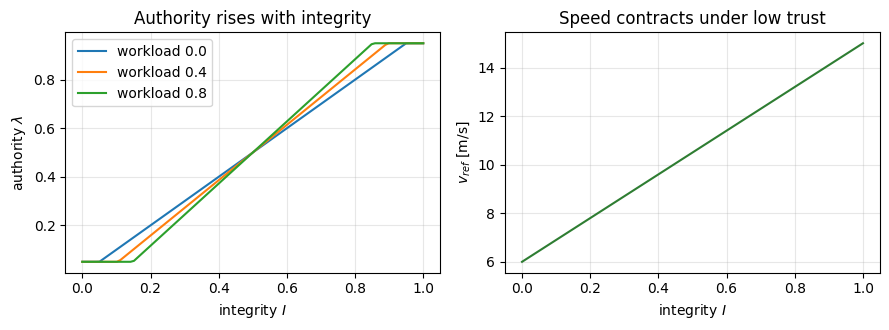

In [2]:
def authority(I, W, avail=True, rho=0.35, lo=0.05, hi=0.95):
    lam = I + rho*W*(I - 0.5)
    if not avail: lam = max(lam, 0.85)
    return np.clip(lam, lo, hi)

I = np.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for W in (0.0, 0.4, 0.8):
    ax[0].plot(I, [authority(i, W) for i in I], label="workload %.1f" % W)
ax[0].set(xlabel="integrity $I$", ylabel="authority $\\lambda$", title="Authority rises with integrity")
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(I, 15*(0.4 + 0.6*I), color="#2e7d32")
ax[1].set(xlabel="integrity $I$", ylabel="$v_{ref}$ [m/s]", title="Speed contracts under low trust")
ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. Conflict: who should win, and why integrity decides

The hardest case is a **conflict**: the automation steers one way, the driver the
other. A fixed authority cannot be right, because *the correct agent depends on who is
actually correct* - and that is precisely what integrity estimates. When perception
is trustworthy ($I$ high $\Rightarrow \lambda$ high) the automation should win a
conflict with a mistaken driver; when perception is out of its domain
($I$ low $\Rightarrow \lambda$ low) the driver should win. Below we simulate both
situations and sweep $\lambda$; the integrity-adaptive choice lands on the right side
of each, where a fixed $\lambda$ cannot.

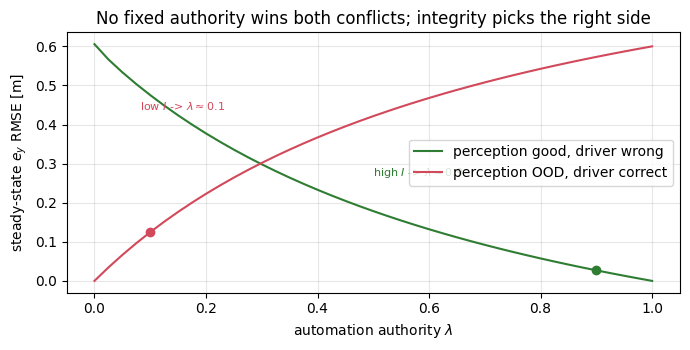

In [3]:
from collections import deque
def sim_conflict(lam, case, n=400, tau=4):
    x = np.array([0.0, 0.0]); buf = deque([np.zeros(2)]*(tau+1), maxlen=tau+1); ey = []
    for _ in range(n):
        buf.append(x.copy()); xd = buf[0]
        if case == "human_wrong":                       # perception good; driver steers to a wrong target
            dA = -KA @ x                                 # automation on the true state (correct)
            dH = -KH @ (xd - np.array([0.6, 0.0]))       # driver holds a wrong lane offset
        else:                                            # "auto_wrong": perception biased; driver correct
            dA = -KA @ (x + np.array([0.6, 0.0]))        # automation on a biased estimate
            dH = -KH @ xd                                # driver on the true state (correct)
        d = np.clip(lam*dA + (1 - lam)*dH, -0.6, 0.6)
        x = A @ x + Bv*d; ey.append(x[0])
    return np.sqrt(np.mean(np.square(ey[-150:])))        # steady-state lateral RMSE

lams = np.linspace(0, 1, 41)
rmse_hw = [sim_conflict(l, "human_wrong") for l in lams]
rmse_aw = [sim_conflict(l, "auto_wrong") for l in lams]

plt.figure(figsize=(7, 3.6))
plt.plot(lams, rmse_hw, color="#2e7d32", label="perception good, driver wrong")
plt.plot(lams, rmse_aw, color="#d1495b", label="perception OOD, driver correct")
plt.scatter([0.9], [sim_conflict(0.9, "human_wrong")], color="#2e7d32", zorder=3)
plt.annotate("high $I$ -> $\\lambda\\approx0.9$", (0.9, sim_conflict(0.9, "human_wrong")), xytext=(0.5, 0.45),
             textcoords="axes fraction", fontsize=8, color="#2e7d32")
plt.scatter([0.1], [sim_conflict(0.1, "auto_wrong")], color="#d1495b", zorder=3)
plt.annotate("low $I$ -> $\\lambda\\approx0.1$", (0.1, sim_conflict(0.1, "auto_wrong")), xytext=(0.12, 0.7),
             textcoords="axes fraction", fontsize=8, color="#d1495b")
plt.xlabel("automation authority $\\lambda$"); plt.ylabel("steady-state $e_y$ RMSE [m]")
plt.title("No fixed authority wins both conflicts; integrity picks the right side")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

The two curves cross: high authority is right when perception is good, low authority
is right when it is not, and **no single $\lambda$ minimises both**. Because our law
sets $\lambda=\Phi(I,W)$, and $I$ is high exactly when perception is trustworthy (as
detected in notebook 06) and low when it is out of domain, the adaptive authority
lands near the minimum of whichever curve is active. That is integrity-aware
arbitration.

## 7. Putting it together

This completes the loop. The vehicle (01) is driven by an LQR (02) reading a state
estimate; when the state comes from perception (03) with uncertainty (04), a Kalman
monitor (05) tests consistency and an integrity score (06) fuses the evidence; that
score sets the shared authority and the speed here in (07). Notebook 08 runs the
whole thing closed-loop and compares it against the naive and hard-handover baselines
across the four scenarios.

### Exercises

1. In the human-only stability panel, read off the critical delay. Increase the human
   gain $K_h$ and show the critical delay shrinks (the crossover-model gain/phase trade).
2. Add the map feed-forward $\delta^{ff}=\arctan(L\kappa)$ to `sim_conflict` on a
   curve and confirm it removes the steady offset regardless of $\lambda$ (notebook 02).
3. Replace the hard clip on $\lambda$ with a smooth saturation and check the blended
   loop stays stable across $\lambda$.
4. Make workload time-varying and let it, not just integrity, drive $\lambda$. When
   should a loaded driver *keep* authority despite decent integrity?

## References

1. SAE International. *Taxonomy and Definitions for Terms Related to Driving Automation Systems for On-Road Motor Vehicles.* Standard J3016_202104, 2021. (Automation levels; minimal-risk condition.)
2. M. R. Endsley. *From Here to Autonomy: Lessons Learned From Human-Automation Research.* Human Factors, 59(1):5-27, 2017. doi:10.1177/0018720816681350
3. N. Merat, A. H. Jamson, F. C. H. Lai, M. Daly, O. M. J. Carsten. *Transition to manual: Driver behaviour when resuming control from a highly automated vehicle.* Transportation Research Part F, 27:274-282, 2014. doi:10.1016/j.trf.2014.09.005
4. D. A. Abbink, M. Mulder, E. R. Boer. *Haptic shared control: smoothly shifting control authority?* Cognition, Technology & Work, 14:19-28, 2012. doi:10.1007/s10111-011-0192-5
5. F. Flemisch, K. Bengler, H. Bubb, H. Winner, R. Bruder. *Towards cooperative guidance and control of highly automated vehicles: H-Mode and Conduct-by-Wire.* Ergonomics, 57(3):343-360, 2014. doi:10.1080/00140139.2013.869355
6. M. Marcano, S. Diaz, J. Perez, E. Irigoyen. *A Review of Shared Control for Automated Vehicles: Theory and Applications.* IEEE Transactions on Human-Machine Systems, 50(6):475-491, 2020. doi:10.1109/THMS.2020.3017748
7. D. T. McRuer, H. R. Jex. *A Review of Quasi-Linear Pilot Models.* IEEE Transactions on Human Factors in Electronics, HFE-8(3):231-249, 1967. doi:10.1109/THFE.1967.234304 (Crossover model.)
8. R. M. Yerkes, J. D. Dodson. *The relation of strength of stimulus to rapidity of habit-formation.* Journal of Comparative Neurology and Psychology, 18:459-482, 1908. doi:10.1002/cne.920180503
9. R. Luo, Y. Weng, Y. Wang, P. Jayakumar et al. *A Workload Adaptive Haptic Shared Control Scheme for Semi-Autonomous Driving.* Accident Analysis & Prevention, 152:105968, 2021. doi:10.1016/j.aap.2020.105968 (arXiv:2004.00167)
10. S. G. Hart, L. E. Staveland. *Development of NASA-TLX (Task Load Index).* Advances in Psychology, 52:139-183, 1988. doi:10.1016/S0166-4115(08)62386-9